# Credit Score classification Project

## Problem Statement
This project focuses on building a machine learning model to classify individuals’ credit scores into predefined categories (such as Poor, Standard, and Good) based on their financial information.
    

### Dataset Explanation
| Column Name              | Description                                                             |
| ------------------------ | ----------------------------------------------------------------------- |
| ID                       | Unique identifier for each record                                       |
| Customer_ID              | Unique identifier for each customer                                     |
| Month                    | Month of the record                                                     |
| Name                     | Customer’s name                                                         |
| Age                      | Age of the customer                                                     |
| SSN                      | Social Security Number                                                  |
| Occupation               | Customer’s occupation                                                   |
| Annual_Income            | Total annual income of the customer                                     |
| Monthly_Inhand_Salary    | Monthly take-home salary                                                |
| Num_Bank_Accounts        | Number of bank accounts held                                            |
| Num_Credit_Card          | Number of credit cards owned                                            |
| Interest_Rate            | Interest rate applied to loans                                          |
| Num_of_Loan              | Total number of loans                                                   |
| Type_of_Loan             | Types of loans taken by the customer                                    |
| Delay_from_due_date      | Average number of days payment is delayed                               |
| Num_of_Delayed_Payment   | Number of delayed payments                                              |
| Changed_Credit_Limit     | Recent change in credit limit                                           |
| Num_Credit_Inquiries     | Number of credit inquiries made                                         |
| Credit_Mix               | Variety of credit types held                                            |
| Outstanding_Debt         | Total unpaid debt                                                       |
| Credit_Utilization_Ratio | Percentage of available credit used                                     |
| Credit_History_Age       | Length of credit history                                                |
| Payment_of_Min_Amount    | Whether minimum payment is made                                         |
| Total_EMI_per_month      | Total monthly EMI payments                                              |
| Amount_invested_monthly  | Monthly investment amount                                               |
| Payment_Behaviour        | Spending and payment behavior pattern                                   |
| Monthly_Balance          | Remaining monthly balance after expenses                                |
| Credit_Score             | Target variable indicating credit score category (Poor, Standard, Good) |



## Importing initial packages

In [90]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore') 
import math

In [91]:
df = pd.read_csv(r'D:\ds ai ml\DS@AI\00-portfolio-projects\02-Credit-score-Classification\credit_score.csv')
df.head(2)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.82262,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.94496,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [93]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

## Data Cleaning

In [94]:
# droping columns which do not add value to analysis
df= df.drop(['ID', 'Customer_ID', 'Name','SSN','Type_of_Loan'],axis = 1)


In [95]:
# column name format
df.columns =( df.columns.str.strip()
               .str.lower()
               .str.replace(' ','_')
)

In [96]:
df.columns

Index(['month', 'age', 'occupation', 'annual_income', 'monthly_inhand_salary',
       'num_bank_accounts', 'num_credit_card', 'interest_rate', 'num_of_loan',
       'delay_from_due_date', 'num_of_delayed_payment', 'changed_credit_limit',
       'num_credit_inquiries', 'credit_mix', 'outstanding_debt',
       'credit_utilization_ratio', 'credit_history_age',
       'payment_of_min_amount', 'total_emi_per_month',
       'amount_invested_monthly', 'payment_behaviour', 'monthly_balance',
       'credit_score'],
      dtype='object')

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   month                     100000 non-null  object 
 1   age                       100000 non-null  object 
 2   occupation                100000 non-null  object 
 3   annual_income             100000 non-null  object 
 4   monthly_inhand_salary     84998 non-null   float64
 5   num_bank_accounts         100000 non-null  int64  
 6   num_credit_card           100000 non-null  int64  
 7   interest_rate             100000 non-null  int64  
 8   num_of_loan               100000 non-null  object 
 9   delay_from_due_date       100000 non-null  int64  
 10  num_of_delayed_payment    92998 non-null   object 
 11  changed_credit_limit      100000 non-null  object 
 12  num_credit_inquiries      98035 non-null   float64
 13  credit_mix                100000 non-null  ob

In [98]:
# Converting to numeric value
credit_age = df['credit_history_age'].str.extract(r'(\d+)\s*Years?\s*and\s*(\d+)\s*Months?')
credit_age.head(2)

,0,1
0,22,1
1,NaN,NaN


In [99]:
df['credit_history_age'] = credit_age[0].astype(float)*12 + credit_age[1].astype(float) # to months

In [100]:
df.head(1)

,month,age,occupation,annual_income,monthly_inhand_salary,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,delay_from_due_date,...,credit_mix,outstanding_debt,credit_utilization_ratio,credit_history_age,payment_of_min_amount,total_emi_per_month,amount_invested_monthly,payment_behaviour,monthly_balance,credit_score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,3,...,_,809.98,26.82262,265.0,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good


### Changing incorrect data types

In [101]:
df[['age', 'annual_income','num_of_loan','num_of_delayed_payment','changed_credit_limit', 'outstanding_debt', 'amount_invested_monthly','monthly_balance']].dtypes

age                        object
annual_income              object
num_of_loan                object
num_of_delayed_payment     object
changed_credit_limit       object
outstanding_debt           object
amount_invested_monthly    object
monthly_balance            object
dtype: object

In [102]:
cols = ['age', 'annual_income','num_of_loan','num_of_delayed_payment','changed_credit_limit', 'outstanding_debt', 'amount_invested_monthly','monthly_balance']

In [103]:
# converting datatype
for col in cols:
    df[col]=pd.to_numeric(df[col], errors = 'coerce')
    

In [104]:
df[['age', 'annual_income','num_of_loan','num_of_delayed_payment','changed_credit_limit', 'outstanding_debt', 'amount_invested_monthly','monthly_balance']].dtypes

age                        float64
annual_income              float64
num_of_loan                float64
num_of_delayed_payment     float64
changed_credit_limit       float64
outstanding_debt           float64
amount_invested_monthly    float64
monthly_balance            float64
dtype: object

In [105]:
for col in df.select_dtypes(exclude =np.number):
    print(f"Column: {col}\n")
    print(f'{df[col].value_counts()}')
    print('----------------------------------------------------------------------------------------')    

Column: month

month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
----------------------------------------------------------------------------------------
Column: occupation

occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64
----------------------------------------------------------------------------------------
Column: credit_mix

credit_mix
Standard    36479
Good        24337
_           20195
Bad         18989
Name: count, dtype: int64
----------------------------------------------------------------------------------------
Colu

The categorical features have inconsistent values and missing values. 

### Function to clean incorrect features

In [106]:
#Create a cleaning function for any column
def clean_column(df, col, col_type="numeric"):
    if col_type == "numeric":
        df[col] = (
            df[col].astype(str)
                  .str.replace(r"[^0-9.\-]", "", regex=True)
                  .replace("", np.nan)
                  .astype(float)
        )
    else:  # text
        df[col] = (
            df[col].astype(str)
                  .str.strip()
                  .str.replace(r"[^a-zA-Z0-9 ]", "", regex=True)
                  .replace("", np.nan)
        )
    return df

In [107]:
for col in df.columns:
    # Decide column type
    if pd.api.types.is_numeric_dtype(df[col]):
        clean_column(df, col, col_type="numeric")
    else:
        clean_column(df, col, col_type="text")
        

In [108]:
for col in df.select_dtypes(exclude =np.number):
    print(f"Column: {col}\n")
    print(f'{df[col].value_counts()}')
    print('_'*120)    

Column: month

month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
________________________________________________________________________________________________________________________
Column: occupation

occupation
Lawyer          6575
Architect       6355
Engineer        6350
Scientist       6299
Mechanic        6291
Accountant      6271
Developer       6235
MediaManager    6232
Teacher         6215
Entrepreneur    6174
Doctor          6087
Journalist      6085
Manager         5973
Musician        5911
Writer          5885
Name: count, dtype: int64
________________________________________________________________________________________________________________________
Column: credit_mix

credit_mix
Standard    36479
Good        24337
Bad         18989
Name: count, dtype: int64
____________________________________________________________________________________

In [109]:
# Changing incorrect values
df['payment_of_min_amount'] = df['payment_of_min_amount'].replace('NM', np.nan)

df['payment_behaviour'] =df['payment_behaviour'].replace(98,np.nan)

In [110]:
# checking any negatives
cols_to_check = df.select_dtypes(exclude = 'object').columns

for col in cols_to_check:
    print(col, (df[col] < 0).sum())

age 886
annual_income 0
monthly_inhand_salary 0
num_bank_accounts 21
num_credit_card 0
interest_rate 0
num_of_loan 3876
delay_from_due_date 591
num_of_delayed_payment 622
changed_credit_limit 1586
num_credit_inquiries 0
outstanding_debt 0
credit_utilization_ratio 0
credit_history_age 0
total_emi_per_month 0
amount_invested_monthly 0
monthly_balance 0


In [111]:
# Replae negatives with NAN
cols_to_check = ['age', 'num_of_loan', 'delay_from_due_date','num_bank_accounts','num_of_delayed_payment', 'changed_credit_limit']

for col in cols_to_check:
    df.loc[df[col] < 0, col] = np.nan

In [112]:
df[cols_to_check].isna().mean() * 100


age                        5.825
num_of_loan                8.661
delay_from_due_date        0.591
num_bank_accounts          0.021
num_of_delayed_payment    10.368
changed_credit_limit       3.677
dtype: float64

### Data cleaning summary
After data cleaning, column formats were standardized, mixed data types in the credit history feature were converted to months, incorrect data types were corrected, and inconsistent feature values were fixed. Negative values were identified and replaced with NaN for proper handling.

## Exploratory Data Analysis (EDA)

In [113]:
# categorical features Summary
df.describe(include='O')

,month,occupation,credit_mix,payment_of_min_amount,payment_behaviour,credit_score
count,100000,92938,79805,87993,100000,100000
unique,8,15,3,2,7,3
top,January,Lawyer,Standard,Yes,LowspentSmallvaluepayments,Standard
freq,12500,6575,36479,52326,25513,53174


### Function to visualize categorical features

In [114]:
def cat_plot(df, cols=None, n_cols = 3):
    # If no columns are provided, select all non-numeric columns
    if cols is None:
        cols = df.select_dtypes(exclude=np.number).columns
        
    if len(cols) == 0:
        print("No categorical columns to plot.")
        return 

    
    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 6*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]

        sns.countplot(
            x=col,
            data=df,
            palette='viridis',
            ax=ax
        )

        ax.set_title(f'Count of {col}', fontsize=18)

        # Rotate x-axis labels
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)

        # Add count labels
        for container in ax.containers:
            ax.bar_label(container, padding=3, fontsize=10)

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


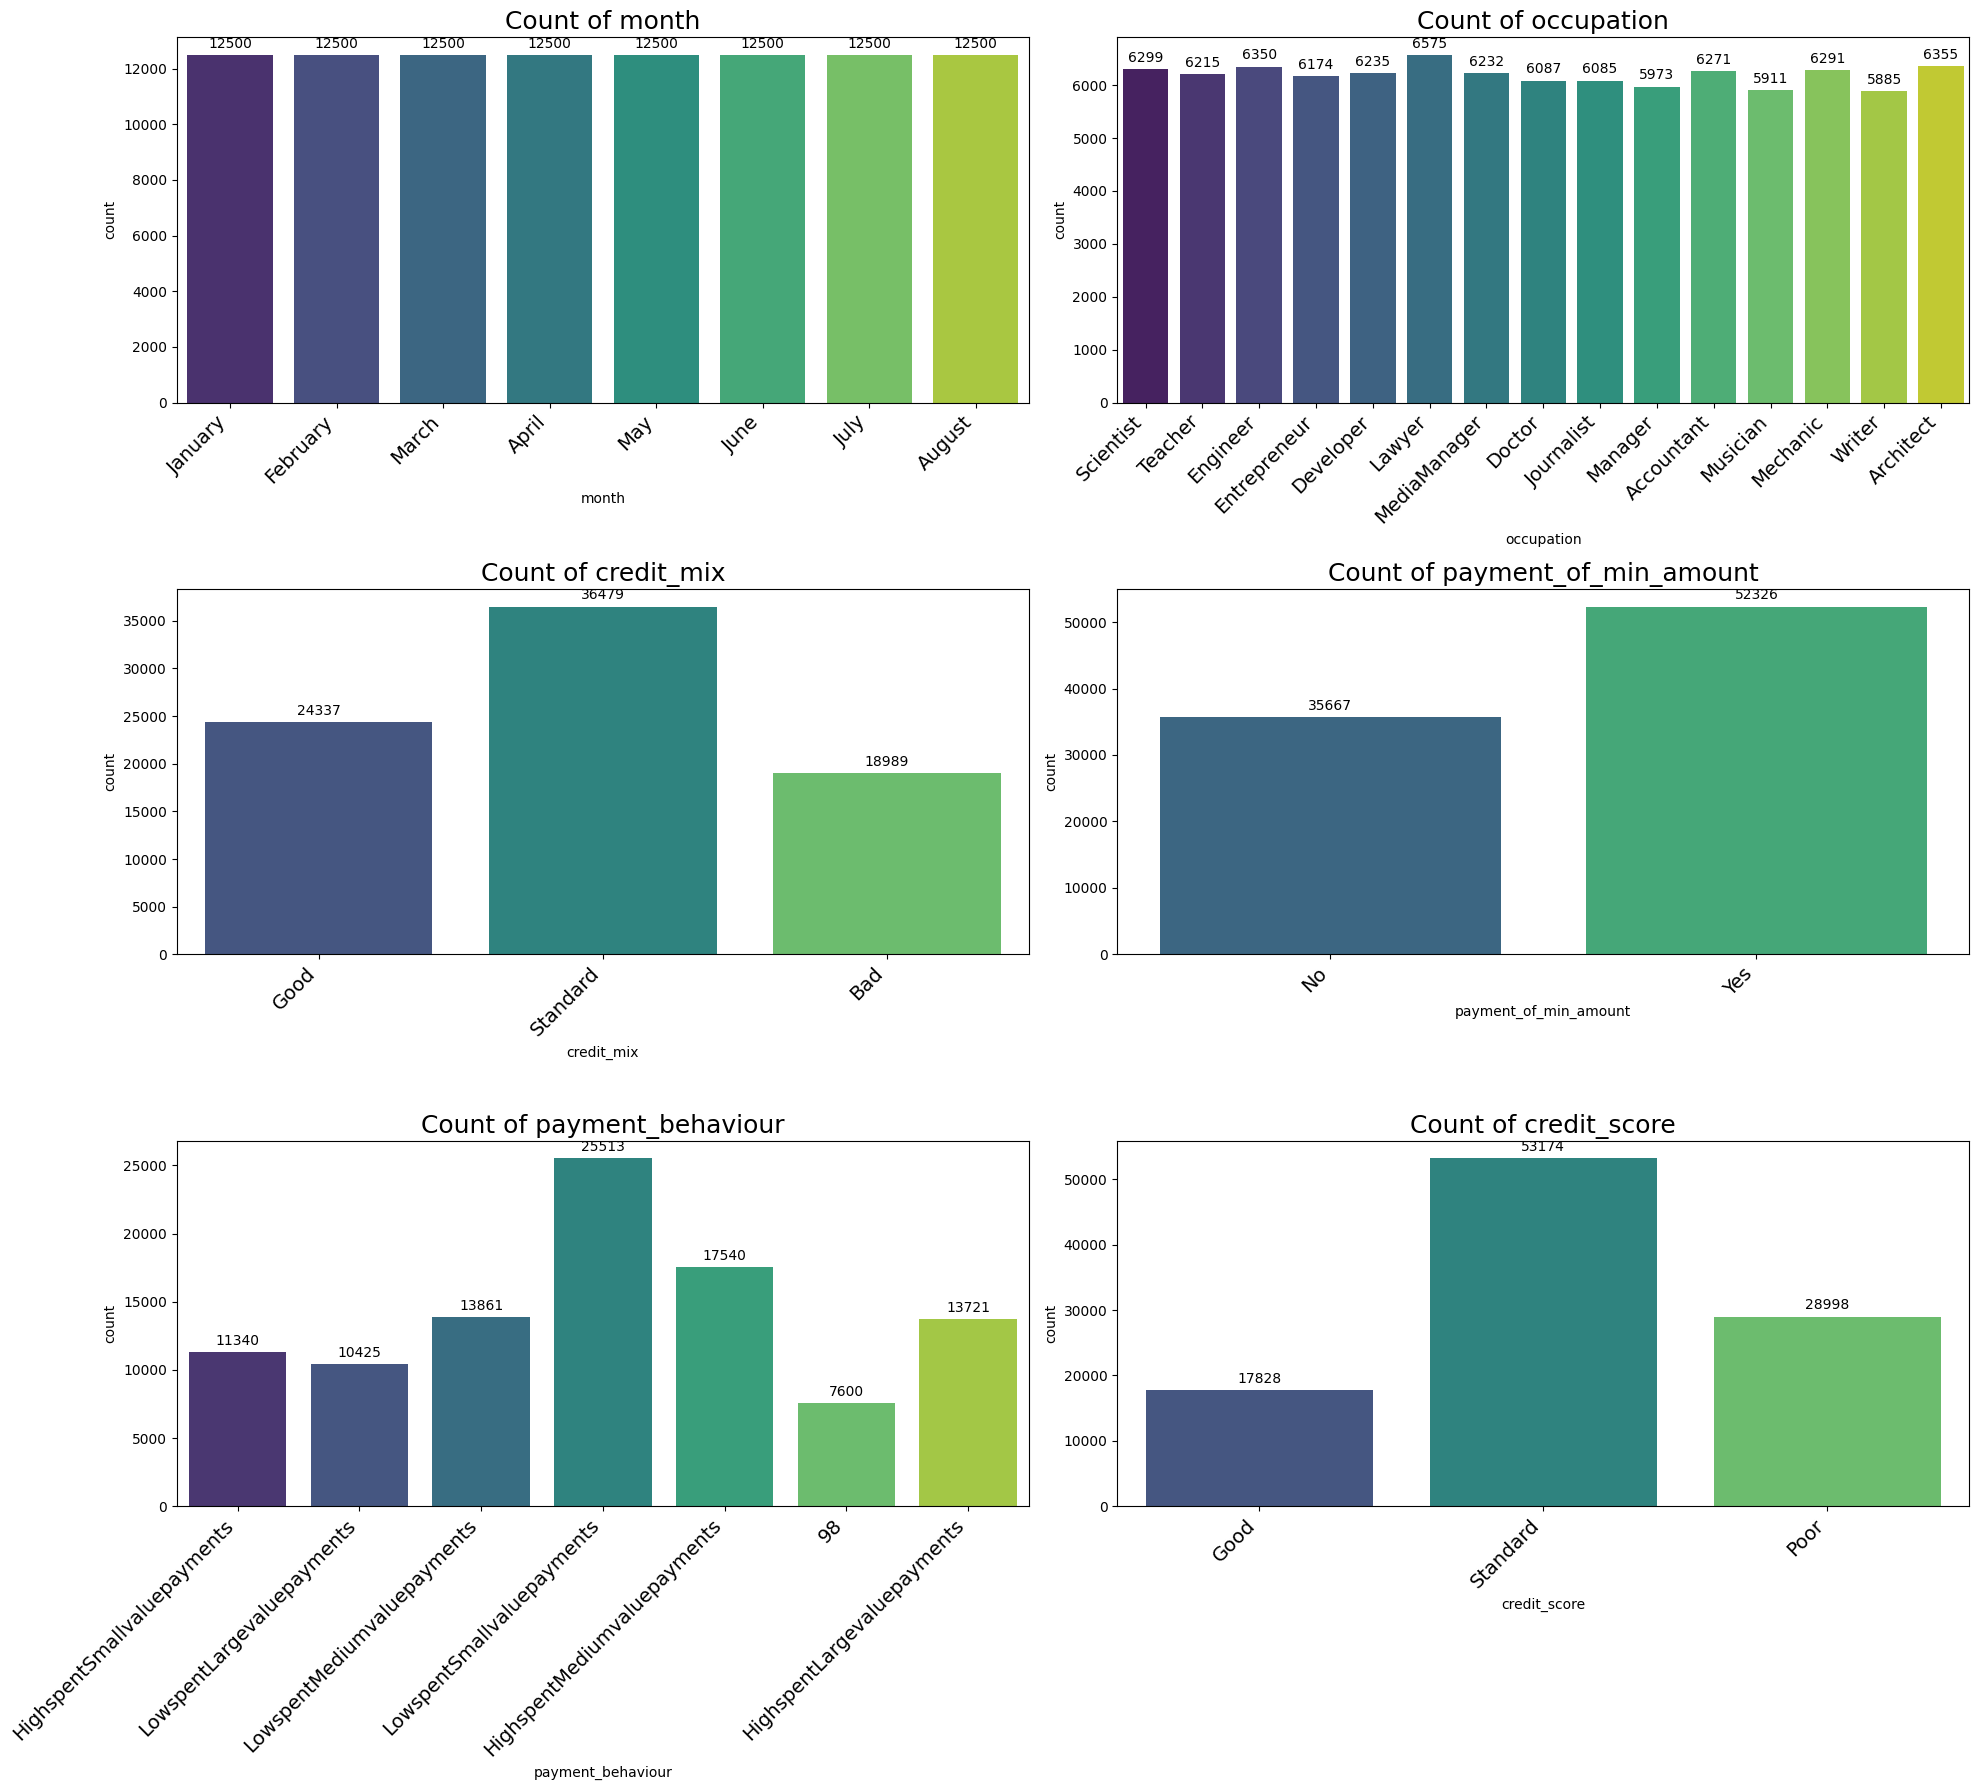

In [115]:
# Distribution of categorical features
cat_plot(df,n_cols = 2)

The target variable shows an imbalanced distribution, with Standard credit scores being more frequent than Good and Poor scores.

In [116]:
# statistical Summary
df.describe().round()

,age,annual_income,monthly_inhand_salary,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,delay_from_due_date,num_of_delayed_payment,changed_credit_limit,num_credit_inquiries,outstanding_debt,credit_utilization_ratio,credit_history_age,total_emi_per_month,amount_invested_monthly,monthly_balance
count,94175.0,93020.0,84998.0,99979.0,100000.0,100000.0,91339.0,99409.0,89632.0,96323.0,98035.0,98991.0,100000.0,90970.0,100000.0,91216.0,98791.0
mean,117.0,178579.0,4194.0,17.0,22.0,72.0,7.0,21.0,31.0,11.0,28.0,1427.0,32.0,221.0,1403.0,196.0,403.0
std,690.0,1442878.0,3184.0,117.0,129.0,466.0,60.0,15.0,228.0,7.0,193.0,1155.0,5.0,100.0,8306.0,200.0,214.0
min,14.0,7006.0,304.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,1.0,0.0,0.0,0.0
25%,25.0,19436.0,1626.0,3.0,4.0,8.0,2.0,10.0,9.0,6.0,3.0,566.0,28.0,144.0,30.0,72.0,270.0
50%,33.0,37551.0,3094.0,6.0,5.0,13.0,3.0,18.0,14.0,10.0,6.0,1166.0,32.0,219.0,69.0,129.0,337.0
75%,42.0,72843.0,5957.0,7.0,7.0,20.0,5.0,28.0,18.0,15.0,9.0,1948.0,36.0,302.0,161.0,237.0,470.0
max,8698.0,24198062.0,15205.0,1798.0,1499.0,5797.0,1496.0,67.0,4397.0,37.0,2597.0,4998.0,50.0,404.0,82331.0,1977.0,1602.0


### Function to visualize data distribution

In [117]:
def hist_plot(df, cols=None, n_cols=3):
   
    # Select numeric columns if cols not provided
    if cols is None:
        cols = df.select_dtypes(include=np.number).columns
    
    if len(cols) == 0:
        print("No numeric columns to plot.")
        return

    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.histplot(
            data=df,
            x=col,
            kde=True,
            ax=axes[i]
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Count', fontsize=12)

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


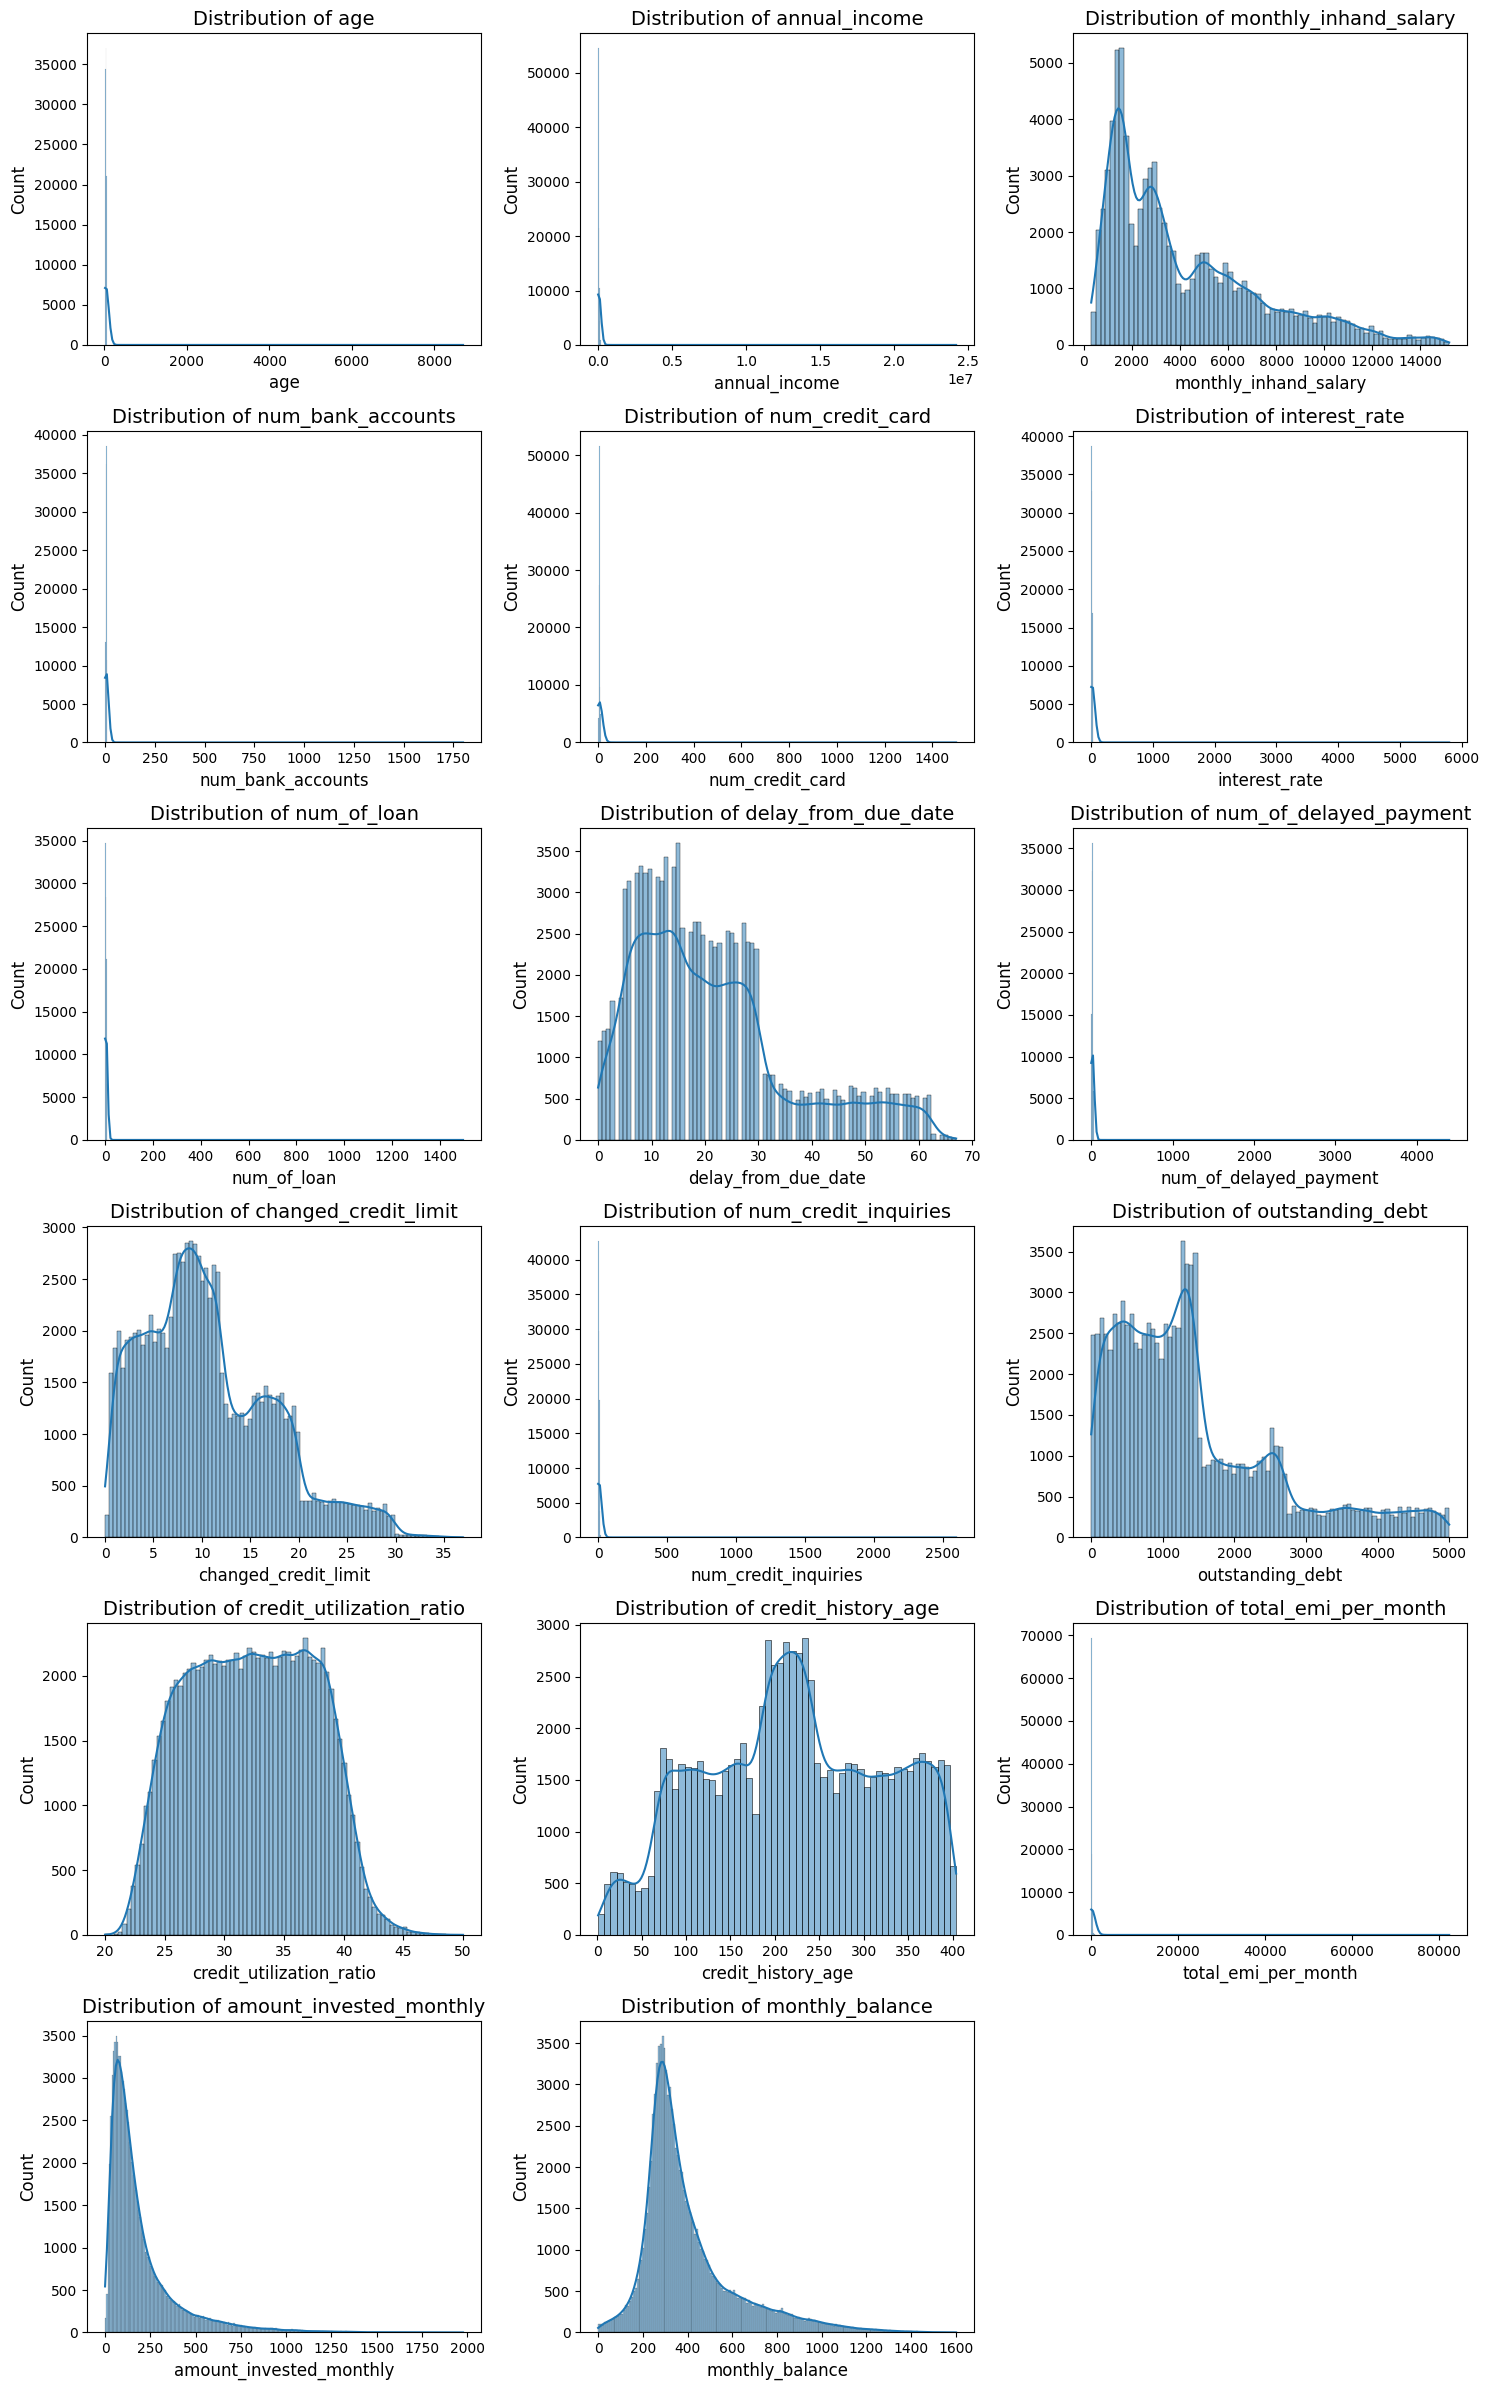

In [118]:
hist_plot(df)

### Outlier analysis Function

The dataset shows skewed distributions and prevalent outliers, requiring appropriate preprocessing before modeling

In [119]:
def box_plot(df, cols=None, n_cols=4, color='skyblue'):
        
    # Select numeric columns if cols not provided
    if cols is None:
        cols = df.select_dtypes(include=np.number).columns
    
    if len(cols) == 0:
        print("No numeric columns to plot.")
        return
    
    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.boxplot(
            y=df[col],
            ax=ax,
            color=color
        )
        ax.set_title(f'Boxplot of {col}', fontsize=14)
        ax.set_ylabel(col, fontsize=12)

    # Remove empty axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


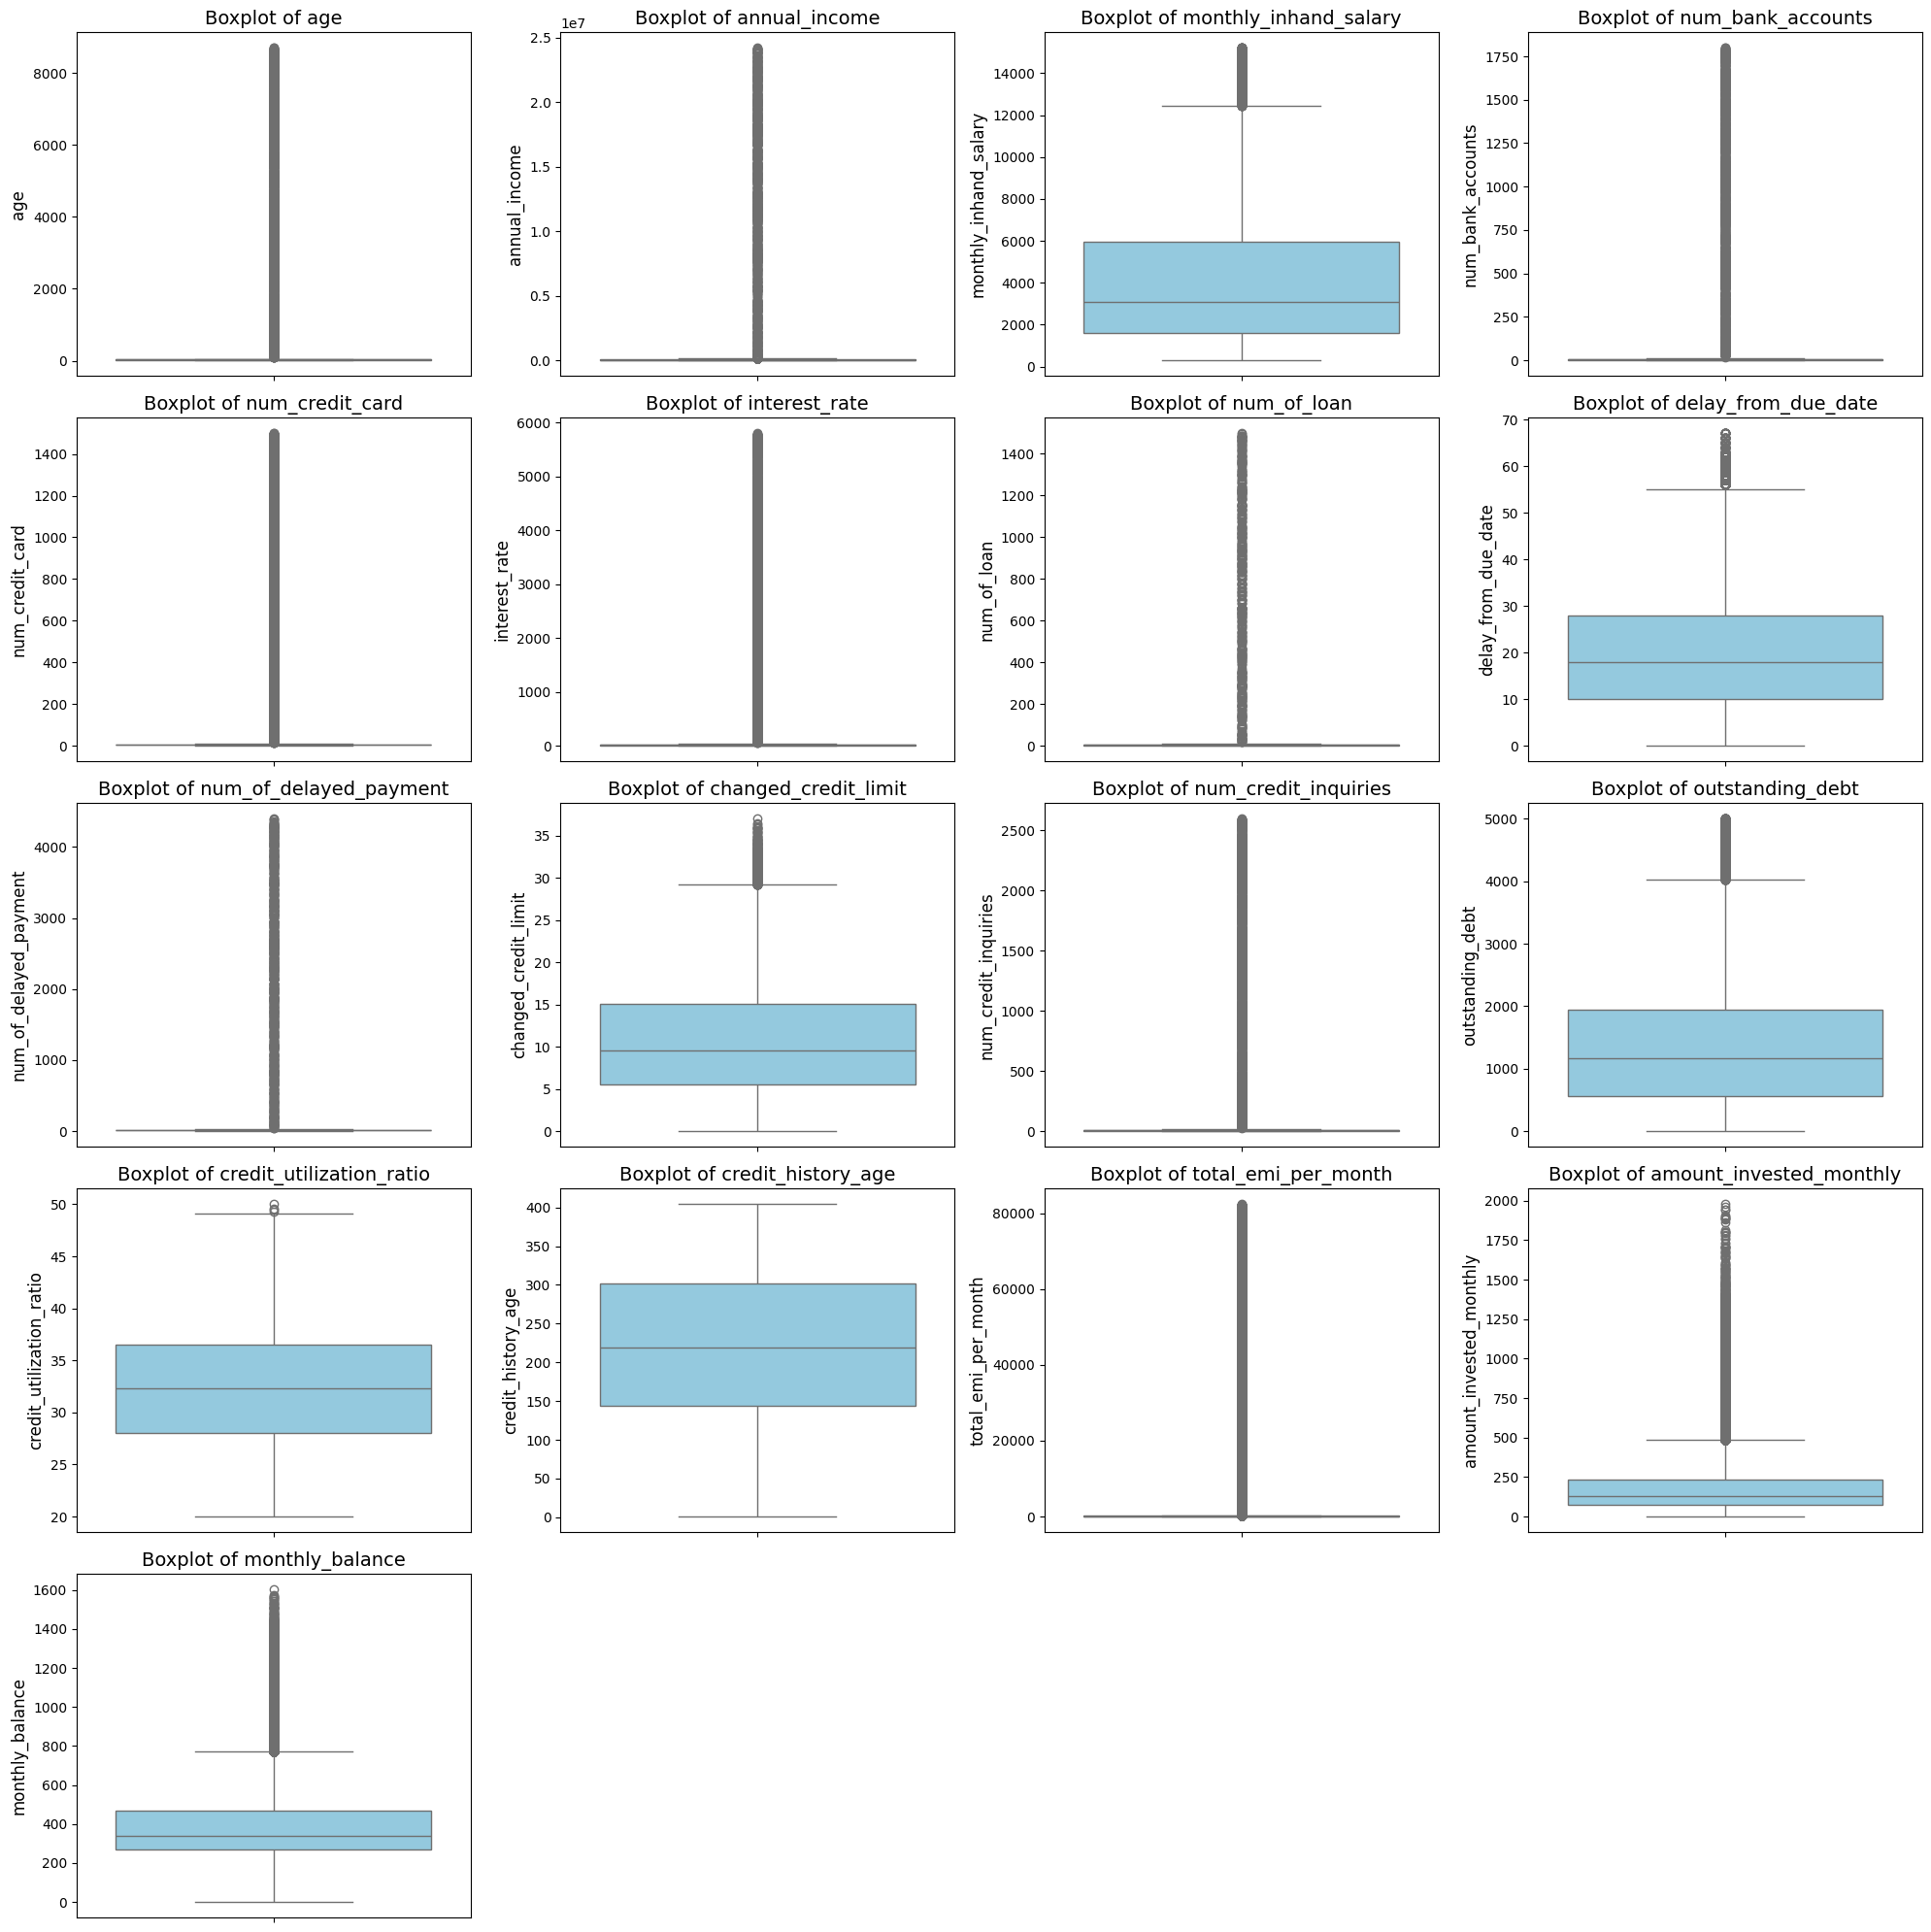

In [120]:
box_plot(df)

The dataset has many outliers that need to be handled for effective model analysis.

In [121]:
# Treating Outliers
cols = df.select_dtypes(include = np.number).columns
for name in cols:
    Q1 = df[name].quantile(0.25)
    Q3 = df[name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[name] = df[name].clip(lower, upper)


In [122]:
df.shape

(100000, 23)

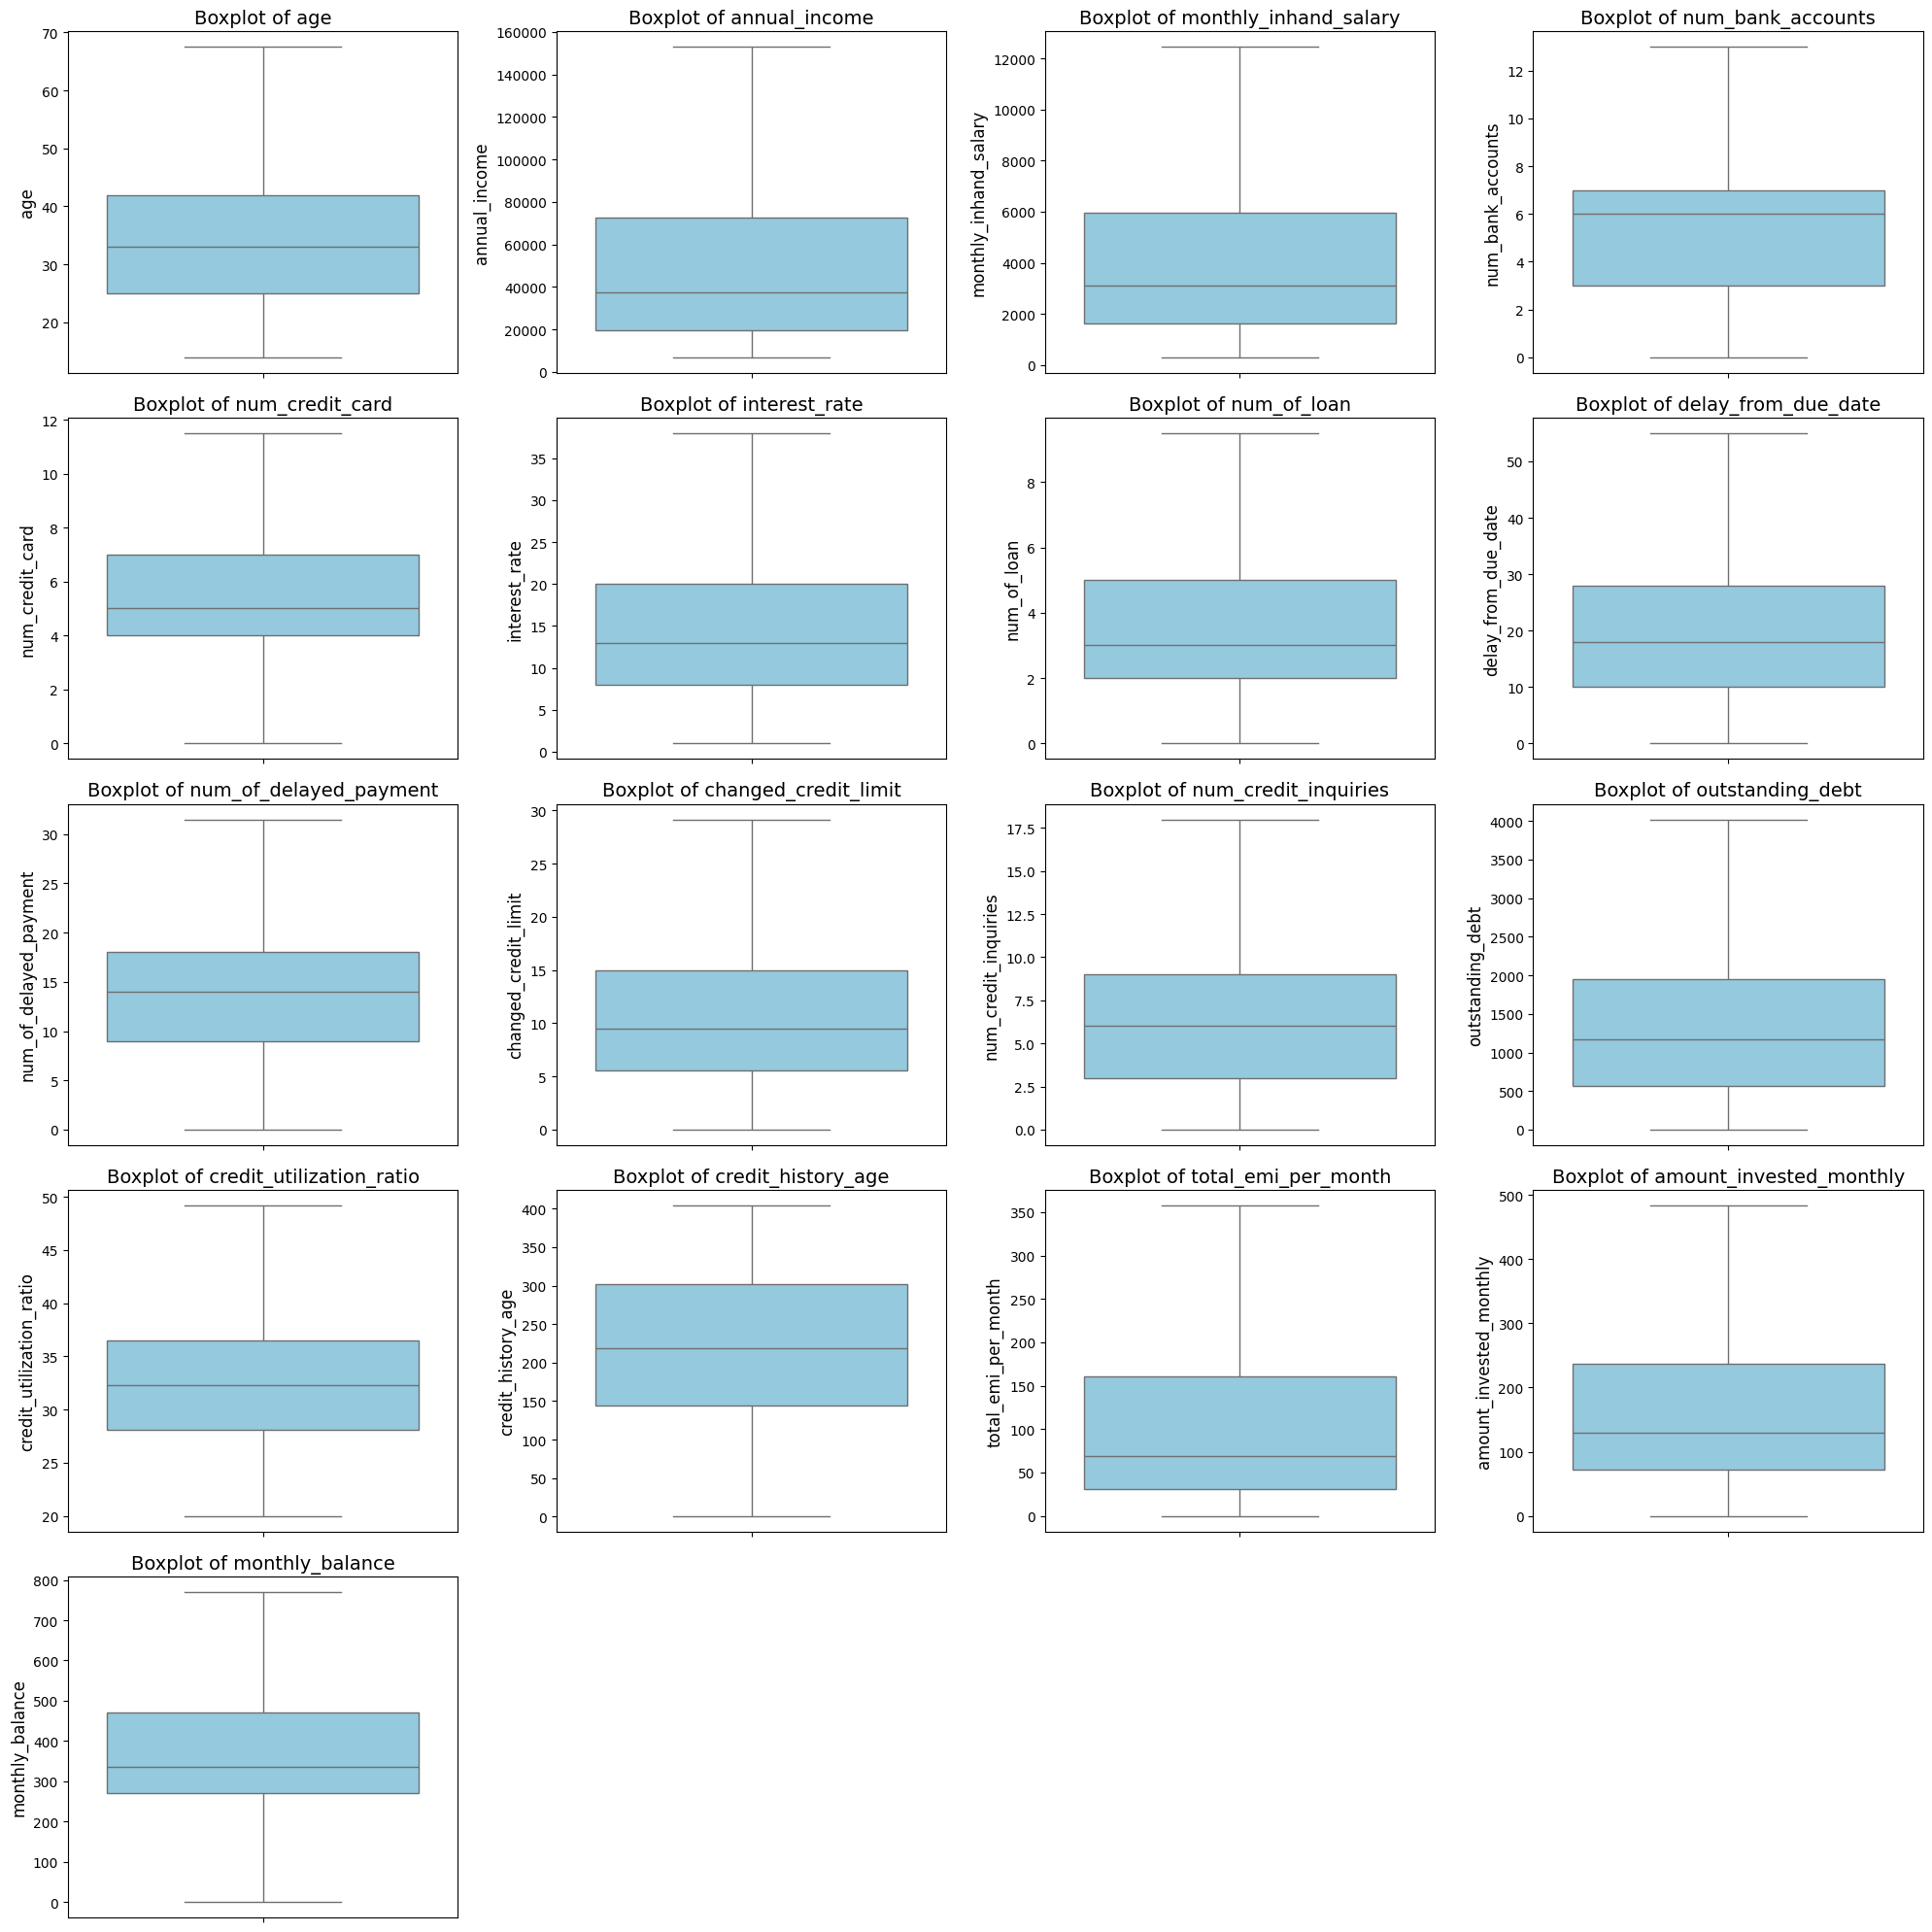

In [123]:
box_plot(df)

After analyzing and treating outliers using a clipping strategy, most features demonstrate stable distributions suitable for credit score modeling.

In [124]:
df.describe()

,age,annual_income,monthly_inhand_salary,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,delay_from_due_date,num_of_delayed_payment,changed_credit_limit,num_credit_inquiries,outstanding_debt,credit_utilization_ratio,credit_history_age,total_emi_per_month,amount_invested_monthly,monthly_balance
count,94175.000000,93020.000000,84998.000000,99979.000000,100000.000000,100000.000000,91339.000000,99409.000000,89632.000000,96323.000000,98035.000000,98991.000000,100000.000000,90970.000000,100000.000000,91216.000000,98791.000000
mean,33.971181,51250.643005,4167.185807,5.469349,5.668825,15.008950,3.563368,21.034081,13.569122,10.589035,5.986770,1400.429230,32.285156,221.195405,108.054040,175.444061,388.340349
std,11.653174,38694.772663,3105.074259,2.718134,2.229002,9.263065,2.476733,14.358881,6.388581,6.609487,4.138214,1086.800228,5.116818,99.741364,104.531770,136.799698,175.173966
min,14.000000,7005.930000,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,25.000000,19435.600000,1625.568229,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.570000,3.000000,566.080000,28.052567,144.000000,30.306660,72.236692,270.106630
50%,33.000000,37550.740000,3093.745000,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.520000,6.000000,1166.370000,32.305784,219.000000,69.249473,128.954538,336.731225
75%,42.000000,72843.380000,5957.448333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,15.010000,9.000000,1948.200000,36.496663,302.000000,161.224249,236.815814,470.262938
max,67.500000,152955.050000,12455.268490,13.000000,11.500000,38.000000,9.500000,55.000000,31.500000,29.170000,18.000000,4021.380000,49.162808,404.000000,357.600632,483.684497,770.497401


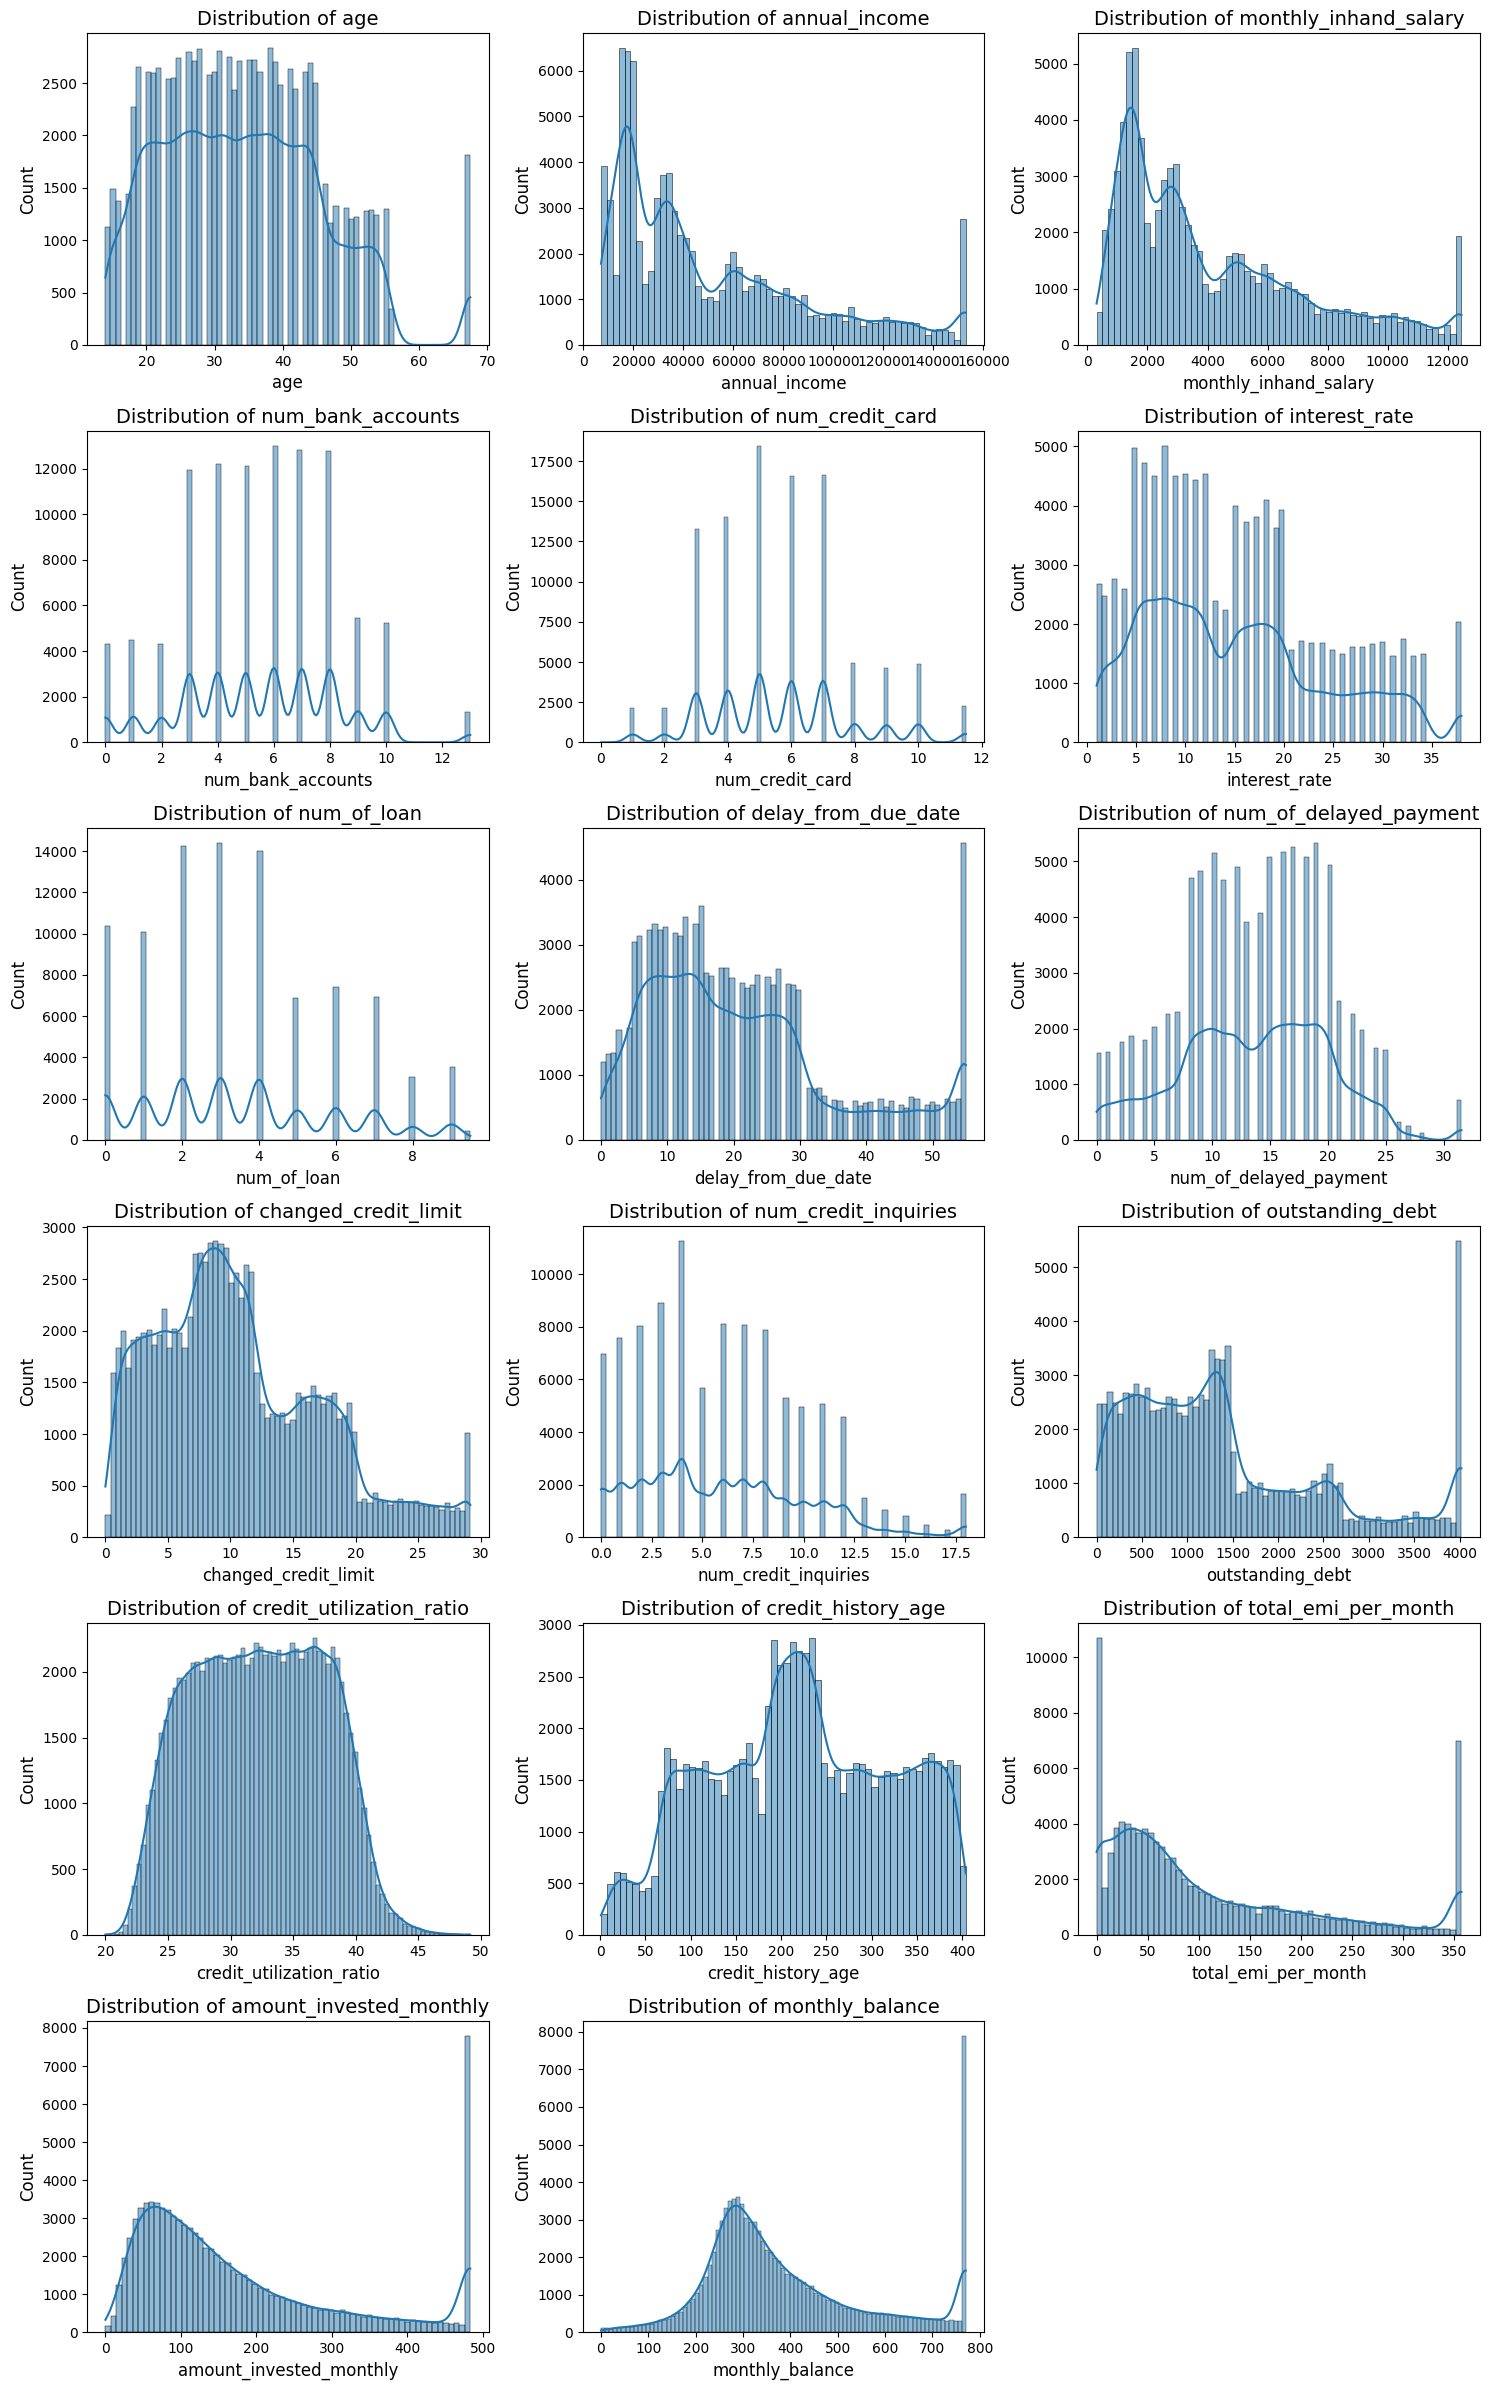

In [125]:
hist_plot(df)

The majority of features exhibit skewed distributions.

### Missisng value Analysis

In [126]:
df.isna().sum()

month                           0
age                          5825
occupation                   7062
annual_income                6980
monthly_inhand_salary       15002
num_bank_accounts              21
num_credit_card                 0
interest_rate                   0
num_of_loan                  8661
delay_from_due_date           591
num_of_delayed_payment      10368
changed_credit_limit         3677
num_credit_inquiries         1965
credit_mix                  20195
outstanding_debt             1009
credit_utilization_ratio        0
credit_history_age           9030
payment_of_min_amount       12007
total_emi_per_month             0
amount_invested_monthly      8784
payment_behaviour               0
monthly_balance              1209
credit_score                    0
dtype: int64

In [127]:
df.duplicated().sum()

np.int64(0)

In [128]:
# Data Imputation
col = df.columns
for col_name in col:
    if df[col_name].dtypes=='object':
        df[col_name] = df[col_name].fillna(df[col_name].mode()[0])   
                                                                          
    else:        
        df[col_name] = df[col_name].fillna(df[col_name].median())
# As most of numerical columns are skewed, imputed with median value. Categorical features were imputed with mode

In [129]:
df.isna().sum()

month                       0
age                         0
occupation                  0
annual_income               0
monthly_inhand_salary       0
num_bank_accounts           0
num_credit_card             0
interest_rate               0
num_of_loan                 0
delay_from_due_date         0
num_of_delayed_payment      0
changed_credit_limit        0
num_credit_inquiries        0
credit_mix                  0
outstanding_debt            0
credit_utilization_ratio    0
credit_history_age          0
payment_of_min_amount       0
total_emi_per_month         0
amount_invested_monthly     0
payment_behaviour           0
monthly_balance             0
credit_score                0
dtype: int64

## Encoding

In [130]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols = df.select_dtypes(include = 'object').columns

encoders = {}
for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
df.head()

,month,age,occupation,annual_income,monthly_inhand_salary,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,delay_from_due_date,...,credit_mix,outstanding_debt,credit_utilization_ratio,credit_history_age,payment_of_min_amount,total_emi_per_month,amount_invested_monthly,payment_behaviour,monthly_balance,credit_score
0,3,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,2,809.98,26.822620,265.0,0,49.574949,80.415295,3,312.494089,0
1,2,23.0,12,19114.12,3093.745000,3.0,4.0,3.0,4.0,18.0,...,1,809.98,31.944960,219.0,0,49.574949,118.280222,4,284.629162,0
2,6,33.0,12,19114.12,3093.745000,3.0,4.0,3.0,4.0,3.0,...,1,809.98,28.609352,267.0,0,49.574949,81.699521,5,331.209863,0
3,0,23.0,12,19114.12,3093.745000,3.0,4.0,3.0,4.0,5.0,...,1,809.98,31.377862,268.0,0,49.574949,199.458074,6,223.451310,0
4,7,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,...,1,809.98,24.797347,269.0,0,49.574949,41.420153,2,341.489231,0


<Axes: >

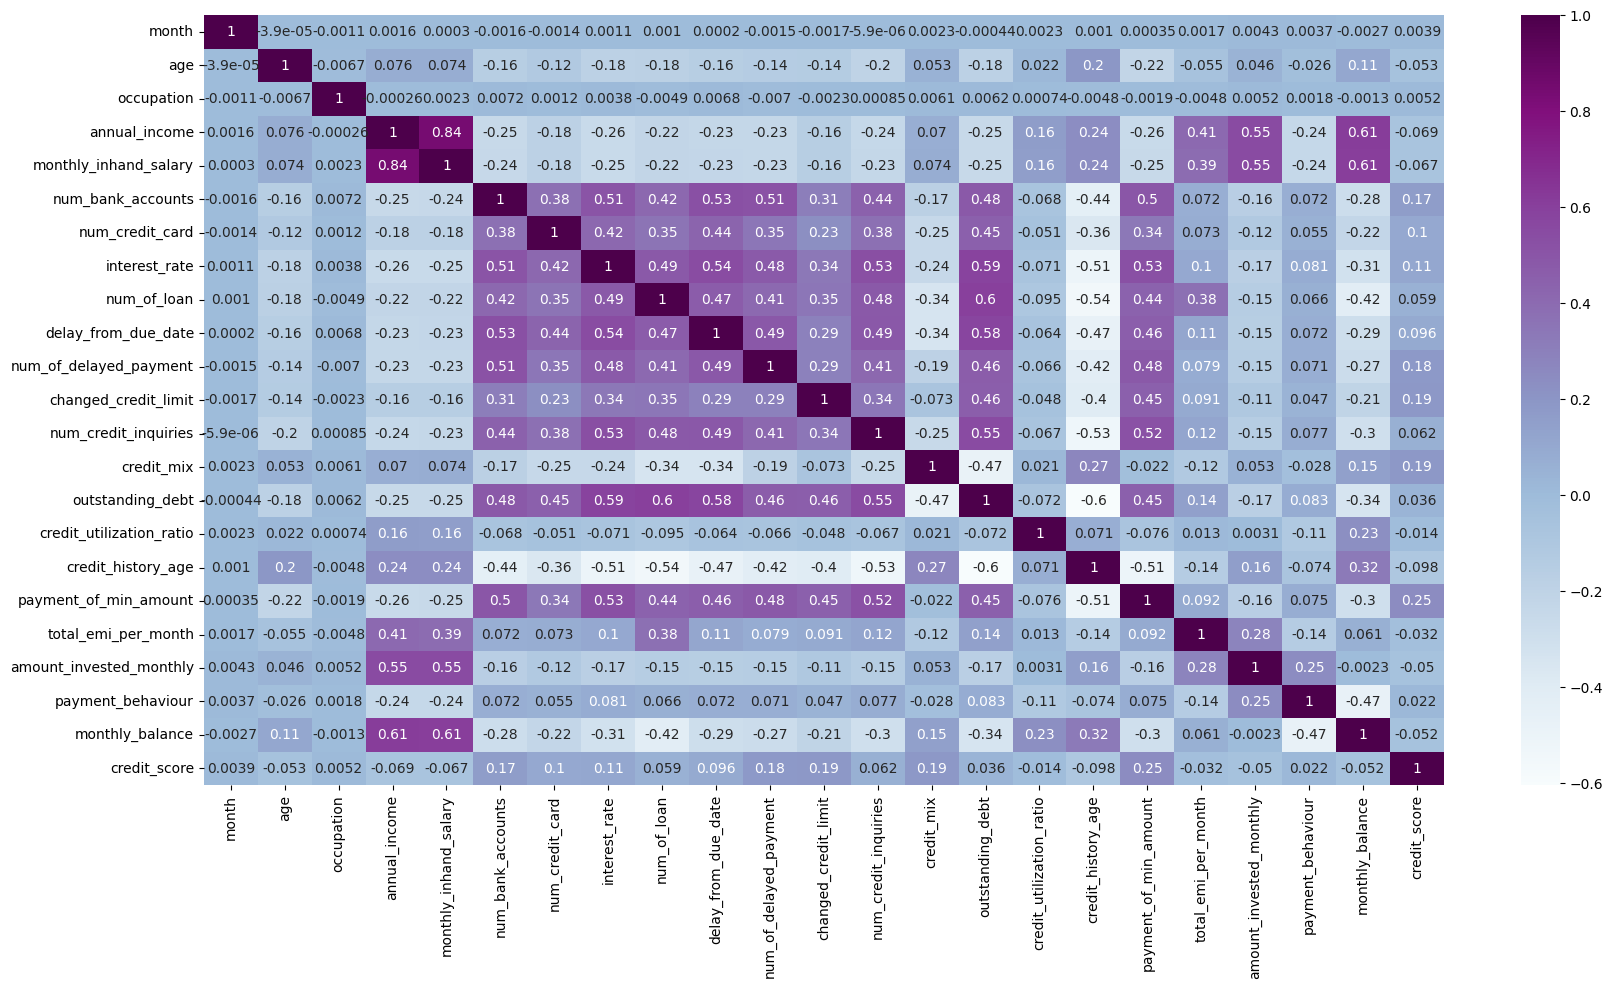

In [131]:
# Correlation analysis
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot = True, cmap= 'BuPu')

The heatmap shows the presence of multicolinearity amont the features. Hence those features were removed using VIF

## Feature selection

### VIF analysis using custom function

In [132]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def reduce_vif(df, target_col=None, thresh=6.0):
    
    # Select numeric columns excluding target
    X = df.select_dtypes(include=[np.number]).copy()
    if target_col:
        X = X.drop(columns=[target_col], errors="ignore")

    # Drop constant columns
    X = X.loc[:, X.nunique() > 1]
    
    while True:
        vif_data = pd.DataFrame({
            "feature": X.columns,
            "VIF": [
                variance_inflation_factor(X.values, i)
                for i in range(X.shape[1])
            ]
        })
        
        max_vif = vif_data["VIF"].max()
                
        if max_vif <= thresh or X.shape[1] <= 1:
            break
        
        # Drop feature with highest VIF
        drop_feature = vif_data.loc[vif_data["VIF"].idxmax(), "feature"]
        print(f"Dropping feature '{drop_feature}' with VIF = {max_vif:.2f}\n")
        
        X = X.drop(columns=[drop_feature])
    
    # Return reduced dataframe including target if needed
    if target_col:
        return pd.concat([X, df[[target_col]]], axis=1)
    
    return X


In [133]:
#VIF
df_lr = reduce_vif(df, target_col='credit_score', thresh=6)

Dropping feature 'credit_utilization_ratio' with VIF = 30.74

Dropping feature 'monthly_balance' with VIF = 16.30

Dropping feature 'monthly_inhand_salary' with VIF = 10.69

Dropping feature 'num_credit_card' with VIF = 9.79

Dropping feature 'num_of_delayed_payment' with VIF = 9.64

Dropping feature 'age' with VIF = 8.73

Dropping feature 'num_bank_accounts' with VIF = 8.27

Dropping feature 'outstanding_debt' with VIF = 7.02

Dropping feature 'interest_rate' with VIF = 6.55

Dropping feature 'credit_history_age' with VIF = 6.54

Dropping feature 'num_of_loan' with VIF = 6.11



Features with a Variance Inflation Factor (VIF) greater than 6 were removed to reduce multicollinearity.

In [134]:
# new df
df_lr

,month,occupation,annual_income,delay_from_due_date,changed_credit_limit,num_credit_inquiries,credit_mix,payment_of_min_amount,total_emi_per_month,amount_invested_monthly,payment_behaviour,credit_score
0,3,12,19114.12,3.0,11.27,4.0,2,0,49.574949,80.415295,3,0
1,2,12,19114.12,18.0,11.27,4.0,1,0,49.574949,118.280222,4,0
2,6,12,19114.12,3.0,9.52,4.0,1,0,49.574949,81.699521,5,0
3,0,12,19114.12,5.0,6.27,4.0,1,0,49.574949,199.458074,6,0
4,7,12,19114.12,6.0,11.27,4.0,1,0,49.574949,41.420153,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,9,39628.99,23.0,11.50,3.0,2,0,35.104023,60.971333,1,1
99996,7,9,39628.99,18.0,11.50,3.0,2,0,35.104023,54.185950,2,1
99997,5,9,39628.99,27.0,11.50,3.0,1,0,35.104023,24.028477,1,1
99998,4,9,39628.99,20.0,11.50,3.0,1,0,35.104023,251.672582,4,2


## Model Building

In [135]:
from sklearn.model_selection import train_test_split
X_lr=df_lr.iloc[:,:-1]
y_lr=df_lr.iloc[:,-1]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2,stratify= y_lr,random_state=1)

In [136]:
X_train_lr

,month,occupation,annual_income,delay_from_due_date,changed_credit_limit,num_credit_inquiries,credit_mix,payment_of_min_amount,total_emi_per_month,amount_invested_monthly,payment_behaviour
44548,7,10,8963.99,55.0,25.25,9.0,2,1,52.056631,128.954538,0
63390,4,7,14968.48,20.0,15.19,14.0,2,1,62.405677,90.846808,5
36893,5,12,19028.45,34.0,16.16,6.0,0,1,78.849133,108.541308,4
12430,4,1,93561.72,29.0,11.78,10.0,2,1,215.353699,71.555254,1
35792,3,8,44280.31,17.0,9.23,1.0,1,0,72.688647,182.186782,6
...,...,...,...,...,...,...,...,...,...,...,...
851,0,7,66528.24,17.0,13.65,2.0,2,1,0.000000,215.618638,2
62318,4,5,14667.26,17.0,5.02,5.0,2,0,11.669519,87.613701,6
52513,2,6,87502.53,20.0,8.35,3.0,2,0,167.959794,287.620676,5
49941,5,6,25527.32,23.0,3.50,3.0,2,0,0.000000,25.795644,2


In [137]:
y_train_lr

44548    1
63390    2
36893    2
12430    2
35792    2
        ..
851      2
62318    2
52513    2
49941    2
41458    1
Name: credit_score, Length: 80000, dtype: int64

In [138]:
#Standardisation
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_lr = sc.fit_transform(X_train_lr)
X_test_lr = sc.transform(X_test_lr)

## Evaluation metric for Multiclass problem 

In [139]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_multiclass_model(model, X_train, y_train, X_test, y_test, average='weighted'):
    
    """
    Evaluates a multiclass classification model on train and test sets.
    
    Parameters:
    - model: trained classifier
    - X_train, y_train: training data
    - X_test, y_test: test data
    - average: metric averaging method for multiclass (default is 'weighted')
        
    Outputs:
    - Evaluation metrics for both training and test sets.
    """
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Function to print metrics
    def print_metrics(y_true, y_pred, dataset_name):
        print(f"--- {dataset_name} ---")
        print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
        print(f"Precision: {precision_score(y_true, y_pred, average=average, zero_division=1):.4f}")
        print(f"Recall:    {recall_score(y_true, y_pred, average=average, zero_division=1):.4f}")
        print(f"F1_score:  {f1_score(y_true, y_pred, average=average, zero_division=1):.4f}")
        print(f"\nConfusion matrix:\n{confusion_matrix(y_true, y_pred)}")
        print(f"\nClassification report:\n{classification_report(y_true, y_pred)}")
        print("\n" + "-"*50 + "\n")
    
    # Print metrics for train and test
    print(f"Model: {model.__class__.__name__}\n")
    print_metrics(y_train, y_train_pred, "Training Set")
    print_metrics(y_test, y_test_pred, "Test Set")
    
    # Quick overfit/underfit check (based on accuracy)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    if train_acc > test_acc + 0.05:
        print("Warning: Possible overfitting (train >> test)")
    elif train_acc < 0.7 and test_acc < 0.7:
        print("Warning: Model may be underfitting (low accuracy)")
    else:
        print("Model seems balanced (no obvious over/underfitting)")



# Analysis of different models 

## Model 1: Logistic Regression

In [140]:
from sklearn.linear_model import LogisticRegression
log_Reg = LogisticRegression(class_weight= 'balanced', random_state= 22)
log_Reg.fit(X_train_lr, y_train_lr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,22
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [141]:
result_lr = evaluate_multiclass_model(log_Reg, X_train_lr, y_train_lr, X_test_lr, y_test_lr, average='weighted')

Model: LogisticRegression

--- Training Set ---
Accuracy:  0.5946
Precision: 0.6385
Recall:    0.5946
F1_score:  0.5984

Confusion matrix:
[[11021   751  2490]
 [ 3321 14343  5535]
 [11016  9316 22207]]

Classification report:
              precision    recall  f1-score   support

           0       0.43      0.77      0.56     14262
           1       0.59      0.62      0.60     23199
           2       0.73      0.52      0.61     42539

    accuracy                           0.59     80000
   macro avg       0.59      0.64      0.59     80000
weighted avg       0.64      0.59      0.60     80000


--------------------------------------------------

--- Test Set ---
Accuracy:  0.5918
Precision: 0.6370
Recall:    0.5918
F1_score:  0.5955

Confusion matrix:
[[2794  191  581]
 [ 847 3531 1421]
 [2814 2310 5511]]

Classification report:
              precision    recall  f1-score   support

           0       0.43      0.78      0.56      3566
           1       0.59      0.61      0.60

Logistic Regression achieved ~59% accuracy with a weighted F1-score of ~0.60 on both training and test sets. While the model generalizes well, its performance indicates underfitting. The model serves as a reliable baseline for comparison with more expressive classifiers.

### Model 1a  Linear Discriminant Analysis (LDA)

In [142]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2) # there are 3 classes


X_train_lda = lda.fit_transform(X_train_lr,y_train_lr)  ### **imp
X_test_lda = lda.transform(X_test_lr)

In [143]:
print('Shape before LDA :',X_train_lr.shape)
print('Shape after LDA  :',X_train_lda.shape)

Shape before LDA : (80000, 11)
Shape after LDA  : (80000, 2)


In [144]:
log_Reg.fit(X_train_lda, y_train_lr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,22
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [145]:
result_lda = evaluate_multiclass_model(log_Reg, X_train_lda, y_train_lr, X_test_lda, y_test_lr, average='weighted')

Model: LogisticRegression

--- Training Set ---
Accuracy:  0.5743
Precision: 0.6255
Recall:    0.5743
F1_score:  0.5786

Confusion matrix:
[[10870   697  2695]
 [ 3553 14189  5457]
 [12495  9162 20882]]

Classification report:
              precision    recall  f1-score   support

           0       0.40      0.76      0.53     14262
           1       0.59      0.61      0.60     23199
           2       0.72      0.49      0.58     42539

    accuracy                           0.57     80000
   macro avg       0.57      0.62      0.57     80000
weighted avg       0.63      0.57      0.58     80000


--------------------------------------------------

--- Test Set ---
Accuracy:  0.5695
Precision: 0.6231
Recall:    0.5695
F1_score:  0.5740

Confusion matrix:
[[2727  184  655]
 [ 917 3509 1373]
 [3210 2271 5154]]

Classification report:
              precision    recall  f1-score   support

           0       0.40      0.76      0.52      3566
           1       0.59      0.61      0.60

Logistic Regression trained on LDA-transformed, VIF-reduced features achieved ~57% accuracy with a weighted F1-score of ~0.57. The model underfits, capturing dominant classes more effectively while struggling with minority patterns, likely due to dimensionality reduction and skewed feature distributions.

## Model 2 - Decision Tree Classifier Model

In [146]:
X= df.iloc[:,:-1]
y = df.iloc[:,-1]

In [147]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = .3,stratify = y, random_state = 22)

# stratify=y: Ensures that the class distribution in y is the same in both X_train, y_train and X_test, y_test. So, the proportion of each class in the training and test sets will match the proportion in the original dataset.

In [148]:
#Standardisation
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [149]:
from sklearn.tree import DecisionTreeClassifier
decision_tree =DecisionTreeClassifier(class_weight = 'balanced', random_state = 22)
decision_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,22
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [150]:
results_dt = evaluate_multiclass_model(decision_tree, X_train, y_train, X_test, y_test, average='weighted')

Model: DecisionTreeClassifier

--- Training Set ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1_score:  1.0000

Confusion matrix:
[[12479     0     0]
 [    0 20299     0]
 [    0     0 37222]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12479
           1       1.00      1.00      1.00     20299
           2       1.00      1.00      1.00     37222

    accuracy                           1.00     70000
   macro avg       1.00      1.00      1.00     70000
weighted avg       1.00      1.00      1.00     70000


--------------------------------------------------

--- Test Set ---
Accuracy:  0.6650
Precision: 0.6641
Recall:    0.6650
F1_score:  0.6645

Confusion matrix:
[[ 3001   360  1988]
 [  354  5498  2847]
 [ 1881  2620 11451]]

Classification report:
              precision    recall  f1-score   support

           0       0.57      0.56      0.57      5349
           1       0.65      0

The Decision Tree achieved 100% training accuracy and ~66.5% test accuracy (F1 ~0.66), indicating clear overfitting. While it perfectly memorizes the training data, generalization is limited, suggesting pruning, parameter tuning, or ensembles are needed.

### Model 2a - Decision tree with hyperparameter tuning

In [151]:
# Random Search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, f1_score

# Base Decision Tree
dtree_tuned = DecisionTreeClassifier(random_state=42)

# Parameter distributions 
param_dist = {
    'max_depth': [5, 7, 9, 11, 13,15],
    'min_samples_leaf': [5,10,15,20],
    'min_samples_split': [10,20,30,40,50 ],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# Macro F1 scorer (best for imbalance)
scorer = make_scorer(f1_score, average='macro')

# Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=dtree_tuned,
    param_distributions=param_dist,
    n_iter=30,        
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit search
random_search.fit(X_train, y_train)

# Best estimator
dtree_tuned = random_search.best_estimator_

# Train final model
dtree_tuned.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Macro F1:", random_search.best_score_)


Best Parameters: {'min_samples_split': 40, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 11, 'class_weight': 'balanced'}
Best CV Macro F1: 0.6524366393611314


In [152]:
dt_tuned =DecisionTreeClassifier(min_samples_split = 30, 
                                 min_samples_leaf =  15, 
                                 max_features=  'log2',
                                 max_depth =  11, 
                                 class_weight = 'balanced')

dt_tuned.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,11
,min_samples_split,30
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [153]:
results_dt_tuned = evaluate_multiclass_model(dt_tuned, X_train, y_train, X_test, y_test, average='weighted')

Model: DecisionTreeClassifier

--- Training Set ---
Accuracy:  0.6604
Precision: 0.7249
Recall:    0.6604
F1_score:  0.6619

Confusion matrix:
[[10548   470  1461]
 [ 2679 15760  1860]
 [ 8504  8799 19919]]

Classification report:
              precision    recall  f1-score   support

           0       0.49      0.85      0.62     12479
           1       0.63      0.78      0.70     20299
           2       0.86      0.54      0.66     37222

    accuracy                           0.66     70000
   macro avg       0.66      0.72      0.66     70000
weighted avg       0.72      0.66      0.66     70000


--------------------------------------------------

--- Test Set ---
Accuracy:  0.6481
Precision: 0.7111
Recall:    0.6481
F1_score:  0.6504

Confusion matrix:
[[4343  234  772]
 [1183 6676  840]
 [3773 3755 8424]]

Classification report:
              precision    recall  f1-score   support

           0       0.47      0.81      0.59      5349
           1       0.63      0.77      

The tuned Decision Tree achieved ~67.5% training accuracy and ~66% test accuracy (F1 ~0.67), showing a much smaller train–test gap and improved generalization compared to the untuned version. While some underfitting remains, the model now balances performance across classes more effectively due to hyperparameter optimization.

### Model 2c - Bagging classifier on tuned Decision Tree

In [154]:
from sklearn.ensemble import BaggingClassifier

# Base Model: Decision Tree  -- #dt_tuned

# Bagging Applied to Decision Tree
bagging_dt = BaggingClassifier(estimator=dt_tuned, n_estimators=50, random_state=42)

# Train Model
bagging_dt.fit(X_train, y_train)

# Evaluate Accuracy
accuracy = bagging_dt.score(X_test, y_test)
print("Model Accuracy with Bagging:", accuracy)



Model Accuracy with Bagging: 0.6810333333333334


In [155]:
results_dt_bagging = evaluate_multiclass_model(bagging_dt, X_train, y_train, X_test, y_test, average='weighted')

Model: BaggingClassifier

--- Training Set ---
Accuracy:  0.6839
Precision: 0.7346
Recall:    0.6839
F1_score:  0.6861

Confusion matrix:
[[10272   299  1908]
 [ 2427 16159  1713]
 [ 7374  8407 21441]]

Classification report:
              precision    recall  f1-score   support

           0       0.51      0.82      0.63     12479
           1       0.65      0.80      0.72     20299
           2       0.86      0.58      0.69     37222

    accuracy                           0.68     70000
   macro avg       0.67      0.73      0.68     70000
weighted avg       0.73      0.68      0.69     70000


--------------------------------------------------

--- Test Set ---
Accuracy:  0.6810
Precision: 0.7303
Recall:    0.6810
F1_score:  0.6835

Confusion matrix:
[[4343  139  867]
 [1046 6889  764]
 [3158 3595 9199]]

Classification report:
              precision    recall  f1-score   support

           0       0.51      0.81      0.63      5349
           1       0.65      0.79      0.71 

Applying Bagging to the hyperparameter-tuned Decision Tree slightly improved generalization, achieving ~68% accuracy and a weighted F1-score of ~0.68 on both training and test sets. The ensemble stabilizes predictions across classes, reducing overfitting compared to a single tree while still showing minor underfitting.

## Model 3: Random Forest Model

In [156]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced_subsample', random_state = 22)
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [157]:
results_rf = evaluate_multiclass_model(random_forest, X_train, y_train, X_test, y_test, average='weighted')

Model: RandomForestClassifier

--- Training Set ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1_score:  1.0000

Confusion matrix:
[[12479     0     0]
 [    0 20299     0]
 [    0     0 37222]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12479
           1       1.00      1.00      1.00     20299
           2       1.00      1.00      1.00     37222

    accuracy                           1.00     70000
   macro avg       1.00      1.00      1.00     70000
weighted avg       1.00      1.00      1.00     70000


--------------------------------------------------

--- Test Set ---
Accuracy:  0.7685
Precision: 0.7676
Recall:    0.7685
F1_score:  0.7674

Confusion matrix:
[[ 3449    44  1856]
 [  207  6601  1891]
 [ 1197  1749 13006]]

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.64      0.68      5349
           1       0.79      0

The Random Forest Classifier achieved 100% accuracy on training and ~77% on the test set, indicating slight overfitting.

### Model 3a Hyperparameter tuning

In [158]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# Base Random Forest
rf = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    n_jobs=-1  # use all cores
)

# Parameter distribution (memory & overfitting controlled)
param_dist = {
    'n_estimators': [50,75,100],        # fewer trees to save memory
    'max_depth': [8, 10, 12, 14],           # controlled depth
    'min_samples_split': [20, 50, 100],     # avoid small splits
    'min_samples_leaf': [5, 10, 20],        # larger leaves to reduce variance
    'max_features': ['sqrt', 'log2'],       # feature randomness
    'class_weight': ['balanced']            # handle class imbalance
}

# Use Macro F1 (good for imbalanced multi-class)
scorer = make_scorer(f1_score, average='macro')

# Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,       # keep moderate to save time
    scoring=scorer,
    cv=3,            # fewer folds for speed
    random_state=42,
    n_jobs=-1,       # parallelize
    verbose=2
)

# Fit search
random_search.fit(X_train, y_train)

# Best estimator
rf_tuned = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Macro F1:", random_search.best_score_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters: {'n_estimators': 75, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 14, 'class_weight': 'balanced'}
Best CV Macro F1: 0.6819430395333582


In [159]:
from sklearn.ensemble import RandomForestClassifier
rf_tuned = RandomForestClassifier(n_estimators = 75, 
                                  min_samples_split =  20,
                                  max_features = 'log2',
                                  max_depth = 14,
                                  class_weight = 'balanced_subsample', 
                                  random_state = 22)
rf_tuned.fit(X_train, y_train)

,n_estimators,75
,criterion,'gini'
,max_depth,14
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [160]:
results_rf_tuned = evaluate_multiclass_model(rf_tuned, X_train, y_train, X_test, y_test, average='weighted')

Model: RandomForestClassifier

--- Training Set ---
Accuracy:  0.7287
Precision: 0.7711
Recall:    0.7287
F1_score:  0.7325

Confusion matrix:
[[10675   199  1605]
 [ 2115 16533  1651]
 [ 7032  6387 23803]]

Classification report:
              precision    recall  f1-score   support

           0       0.54      0.86      0.66     12479
           1       0.72      0.81      0.76     20299
           2       0.88      0.64      0.74     37222

    accuracy                           0.73     70000
   macro avg       0.71      0.77      0.72     70000
weighted avg       0.77      0.73      0.73     70000


--------------------------------------------------

--- Test Set ---
Accuracy:  0.7013
Precision: 0.7424
Recall:    0.7013
F1_score:  0.7050

Confusion matrix:
[[4346  116  887]
 [ 990 6859  850]
 [3060 3059 9833]]

Classification report:
              precision    recall  f1-score   support

           0       0.52      0.81      0.63      5349
           1       0.68      0.79      

The hyperparameter-tuned Random Forest achieved ~73% training accuracy and ~70% test accuracy (F1 ~0.71), showing balanced performance with no clear overfitting or underfitting. Hyperparameter optimization improved generalization and class-wise stability, providing consistent predictions across all target classes

### Model 3b- Bagging with tuned Random Forest

In [161]:
from sklearn.ensemble import BaggingClassifier

# Base Model: rf_tuned

# Bagging Applied to Random forest model
bagging_rf = BaggingClassifier(estimator=rf_tuned, n_estimators=10, random_state=42)

# Train Model
bagging_rf.fit(X_train, y_train)

# Evaluate Accuracy
accuracy = bagging_rf.score(X_test, y_test)
print("Model Accuracy with Bagging:", accuracy)



Model Accuracy with Bagging: 0.6985666666666667


In [162]:
results_bagging_rf = evaluate_multiclass_model(bagging_rf, X_train, y_train, X_test, y_test, average='weighted')

Model: BaggingClassifier

--- Training Set ---
Accuracy:  0.7173
Precision: 0.7588
Recall:    0.7173
F1_score:  0.7212

Confusion matrix:
[[10356   223  1900]
 [ 2223 16348  1728]
 [ 7063  6654 23505]]

Classification report:
              precision    recall  f1-score   support

           0       0.53      0.83      0.64     12479
           1       0.70      0.81      0.75     20299
           2       0.87      0.63      0.73     37222

    accuracy                           0.72     70000
   macro avg       0.70      0.76      0.71     70000
weighted avg       0.76      0.72      0.72     70000


--------------------------------------------------

--- Test Set ---
Accuracy:  0.6986
Precision: 0.7397
Recall:    0.6986
F1_score:  0.7023

Confusion matrix:
[[4313  123  913]
 [1003 6853  843]
 [3044 3117 9791]]

Classification report:
              precision    recall  f1-score   support

           0       0.52      0.81      0.63      5349
           1       0.68      0.79      0.73 

Applying Bagging to the hyperparameter-tuned Random Forest achieved ~70% test accuracy and F1-score ~0.70, with balanced performance across all classes.

## Final Model Evaluation for Credit Score Classification

- Logistic Regression & LDA: Accuracy ~57–60%, F1 ~0.58–0.61. The model underfits, performing better on dominant classes (Standard and Poor) while struggling with the minority (Good) class. Performance is limited by linear assumptions, feature reduction, and skewed data.

- Decision Tree (default & tuned): Accuracy ~66–68%, F1 ~0.66–0.68. Hyperparameter tuning improved generalization, and Bagging further stabilized predictions across classes, reducing variance compared to a single tree.

- Random Forest (default & tuned): Accuracy ~70–77%, F1 ~0.71–0.77. Default RF shows slight overfitting, while hyperparameter tuning balances performance across all classes and improves generalization.

- Bagging on Tuned Random Forest: Accuracy ~70–72%, F1 ~0.70–0.72. The ensemble maintains stable predictions and robust class-wise performance, slightly reducing variance without significantly changing overall accuracy.

### Conclusion

The hyperparameter-tuned Random Forest and Bagging on Random Forest are the strongest models for credit score classification. They offer balanced accuracy, precision, recall, and F1 across all classes, handle class imbalance better than linear models, and generalize well. Bagging improves stability marginally, making the **tuned Random Forest the optimal choice for deployment**.

## Model deployment

In [163]:
import joblib
joblib.dump(rf_tuned,'rf_tuned.pkl')
joblib.dump(sc, 'sc.pkl')
joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']

In [164]:
import gradio as gr
import pandas as pd
import joblib

# Load model and preprocessors
model = joblib.load("rf_tuned.pkl")
sc = joblib.load("sc.pkl")
encoders = joblib.load("encoders.pkl")

features = [
    'month', 'age', 'occupation', 'annual_income', 'monthly_inhand_salary',
    'num_bank_accounts', 'num_credit_card', 'interest_rate', 'num_of_loan',
    'delay_from_due_date', 'num_of_delayed_payment', 'changed_credit_limit',
    'num_credit_inquiries', 'credit_mix', 'outstanding_debt',
    'credit_utilization_ratio', 'credit_history_age',
    'payment_of_min_amount', 'total_emi_per_month',
    'amount_invested_monthly', 'payment_behaviour', 'monthly_balance'
]

categorical_cols = [
    'month', 'occupation', 'credit_mix',
    'payment_of_min_amount', 'payment_behaviour'
]

def safe_label_encode(col, value):
    le = encoders[col]

    if value in le.classes_:
        return le.transform([value])[0]
    else:
        # fallback to most frequent / first class
        return le.transform([le.classes_[0]])[0]

def predict_credit_score(
    month, age, occupation, annual_income, monthly_inhand_salary,
    num_bank_accounts, num_credit_card, interest_rate, num_of_loan,
    delay_from_due_date, num_of_delayed_payment, changed_credit_limit,
    num_credit_inquiries, credit_mix, outstanding_debt,
    credit_utilization_ratio, credit_history_age,
    payment_of_min_amount, total_emi_per_month,
    amount_invested_monthly, payment_behaviour, monthly_balance
):
    data = locals()
    row = []

    for col in features:
        val = data[col]

        if col in categorical_cols:
            val = safe_label_encode(col, val.strip())
        else:
            val = float(val)

        row.append(val)

    X = pd.DataFrame([row], columns=features)
    X_scaled = sc.transform(X)

    prediction_encoded = model.predict(X_scaled)[0]
    prediction_label = encoders['credit_score'].inverse_transform([prediction_encoded])[0]

    return prediction_label
  
inputs = [
    gr.Textbox(label="Month "),
    gr.Number(label="Age"),
    gr.Textbox(label="Occupation"),
    gr.Number(label="Annual Income"),
    gr.Number(label="Monthly Inhand Salary"),
    gr.Number(label="Number of Bank Accounts"),
    gr.Number(label="Number of Credit Cards"),
    gr.Number(label="Interest Rate"),
    gr.Number(label="Number of Loans"),
    gr.Number(label="Delay From Due Date"),
    gr.Number(label="Number of Delayed Payments"),
    gr.Number(label="Changed Credit Limit"),
    gr.Number(label="Number of Credit Inquiries"),
    gr.Textbox(label="Credit Mix"),
    gr.Number(label="Outstanding Debt"),
    gr.Number(label="Credit Utilization Ratio"),
    gr.Number(label="Credit History Age"),
    gr.Textbox(label="Payment of Min Amount (Yes / No / NM)"),
    gr.Number(label="Total EMI per Month"),
    gr.Number(label="Amount Invested Monthly"),
    gr.Textbox(label="Payment Behaviour"),
    gr.Number(label="Monthly Balance")
]

examples = [
    [4.0, 48.0, 5.0, 20787.69, 1999.3075, 8.0, 6.0, 14.0, 3.0, 23.0, 14.0, 1.13, 3.0, 2.0, 614.6, 26.110243, 219.0, 0.0, 42.221993, 258.215174, 6.0, 189.493584],
    [1.0, 48.0, 5.0, 20787.69, 1999.3075, 8.0, 11.5, 14.0, 3.0, 22.0, 14.0, 8.13, 3.0, 2.0, 614.6, 35.344188, 221.0, 0.0, 42.221993, 21.745531, 1.0, 375.963226]
]

interface = gr.Interface(
    fn=predict_credit_score,
    inputs=inputs,
    outputs=gr.Textbox(label="Predicted Credit Score"),
    examples=examples,
    cache_examples=False,
    title="Credit Score Classification API",
    description="Credit score prediction"
)

if __name__ == "__main__":
    interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7864

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
